# Spectral Sensitivity Analysis: Jacobians, Linear-Gaussian Approximations, and Information Content

Users should cite Batalha & Wogan 2026 RASTI 

In this tutorial you will learn how to: 

1. Use PICASO's Jacobian function 
2. Use PICASO's infromation statistics packages 
3. Reproduce the IC statistics example shown in Batalha & Wogan (submitted)

You should already be familiar with the basics of computing a reflected light spectrum with PICASO. 

In [1]:
import numpy as np
import pandas as pd
import os
import astropy.units as u


from picaso import justdoit as jdi 
from picaso import justplotit as jpi 
import picaso.information_content as ic

from matplotlib import pyplot as plt

jpi.output_notebook()

Loading BokehJS ...

## Pick Initial State Vector

This is equivalent to setting $x_a$ as defined in Batalha & Wogan

In [2]:
#opacity file can be found here: https://zenodo.org/records/17381172
opacity = jdi.opannection(wave_range=[0.35,1.8], 
        filename_db='/data2/nwogan/wogan_opacities/HELIOS-K/opacities_photochem_0.1_250.0_R15000_v2.db')

For this simple example, we will assume an isothermal PT profile and constant volume mixing ratio abundances. This tutorial is just meant to build intuition surrounding how to compute and leverage IC statistics. 

In [3]:
pressure = np.logspace(-6,0,90)
temperature = 280+0*pressure

df_atmosphere = pd.DataFrame({
    'pressure':    pressure,
    'temperature': temperature,
    'H2O':  0.1,
    'CO2':  0.1,
    'N2':   0.8,
})

In [4]:
example = jdi.inputs()

# Phase angle 
example.phase_angle(0) #radians

# Define gravity
example.gravity(radius=1, radius_unit=jdi.u.Unit('R_earth'),
                mass=1, mass_unit=jdi.u.Unit('M_earth')) #any astropy units available
example.approx(raman="none")

# Define star 
example.star(opacity,5778,0,4.0,semi_major=1, radius=1, radius_unit=jdi.u.Unit('R_sun'), 
            semi_major_unit=u.Unit('au')) 

example.surface_reflect(0.05,opacity.wno)

example.atmosphere(df=df_atmosphere)

# Define clouds
ptop = 0.6
pbot = 0.7
logdp = np.log10(pbot) - np.log10(ptop)  
log_pbot = np.log10(pbot)
example.clouds(w0=[0.97], g0=[0.85], 
                p = [log_pbot], dp = [logdp], opd=[10],do_holes=True, fhole=0.5,fthin_cld=1)
# Cloudy spectrum
df = example.spectrum(opacity,full_output=True)

In [5]:
xspec,yspec = jdi.mean_regrid(df['wavenumber'], df['fpfs_reflected'],R=300)
jpi.show(jpi.spectrum(xspec,yspec,y_range=[1e-10, 6e-10]))

## Compute Jacobian 

Now we will compute the Jacobian, $K_a$, as defined in Batalha & Wogan. 

As explaiend in Batalha & Wogan, choosing the perturbation value here is important. We will start the tutorial by computing the Jacobian for many perturbation values.

In [6]:

perturb_example = ic.copy.deepcopy(example)

### Formalism for defining jacobian parameters 

The formalism for definite the jacobian parameters in PICASO depends on if the value you wish to perturb is included in the `example.inputs` class or if it is a function. Here we will show a mixutre of both. 

First let's consider the example of H2O, which can be found in the example.inputs class here:

In [7]:
example.inputs['atmosphere']['profile']['H2O']

0     0.1
1     0.1
2     0.1
3     0.1
4     0.1
     ... 
85    0.1
86    0.1
87    0.1
88    0.1
89    0.1
Name: H2O, Length: 90, dtype: float64

To specify that we want this to be perturbed we provide the str input: 

`atmosphere.profile.H2O` which is the **dot separated dictionary path to the value you want to perturb**


Now let's say we wanted to perturb `dp` in the clouds function which is not specifically archived in the picaso inputs dictionary. In this case we specify `def`, the function name, then the input argument: 

For example if perturbing this function: 

`example.clouds(w0=[0.97], g0=[0.85],  p = [log_pbot], dp = [logdp])` 

we would simply specify: 

`def.clouds.dp`

If choosing the latter option (`def.clouds.dp`) users must input a `def_kwargs` as shown below. `def_kwargs` specifies to `picaso` what other arguments in the function `clouds` needs to be held constant while pertrubing the paramter of interest (in this case `dp`)

Let's try

In [8]:
#define jacobian parameters 
jac_params = ['atmosphere.profile.H2O', 'atmosphere.profile.CO2', 'planet.gravity', 'def.clouds.dp']

In [9]:

#define if they should be perturbed in log space 
is_log=[True]*len(jac_params)

# lets compute the Jacobian using center and forward differencing over 
# a range of perturbation balues  
results = {}
for d_param in [0.01, 0.1, 0.2,0.3,0.4 ] :
    print(d_param)
    jac_mat_class_center = ic.jacobian(
        picaso_class = perturb_example, #this defines x_a
        params = jac_params, #this defines the jacobian parameters above 
        is_log=is_log, #defines log or not 
        d_param=d_param,#defines perturbation 
        calculation='albedo',#could be reflected, thermal, or transmission
        opacityclass=opacity, #provides the opacities 
        method='center', #sets jacobian finite differencing method (center, forward, backward)
        #this defines the other parameters that will be regarded as fixed when running the clouds function
        def_kwargs = {'def.clouds.dp':dict(w0=[0.97], g0=[0.85], p = [log_pbot], dp = np.array([logdp]), opd=[10],do_holes=True,fhole=0.5,fthin_cld=1)}) 


    jac_mat_class_foward = ic.jacobian(
        picaso_class = perturb_example, params = jac_params, is_log=is_log,d_param=d_param,
        calculation='albedo', opacityclass=opacity, method='forward',
            def_kwargs = {'def.clouds.dp':dict(w0=[0.97], g0=[0.85], p = [log_pbot], dp = np.array([logdp]), opd=[10],do_holes=True,fhole=0.5,fthin_cld=1)}) 


    results[d_param] = [jac_mat_class_foward, jac_mat_class_center]

0.01


0.1


0.2


0.3


0.4


## Determine how Jacobian is sensitive to perturbation choice

Reproducing Figure 1, Batalha & Wogan 2026 RASTI 

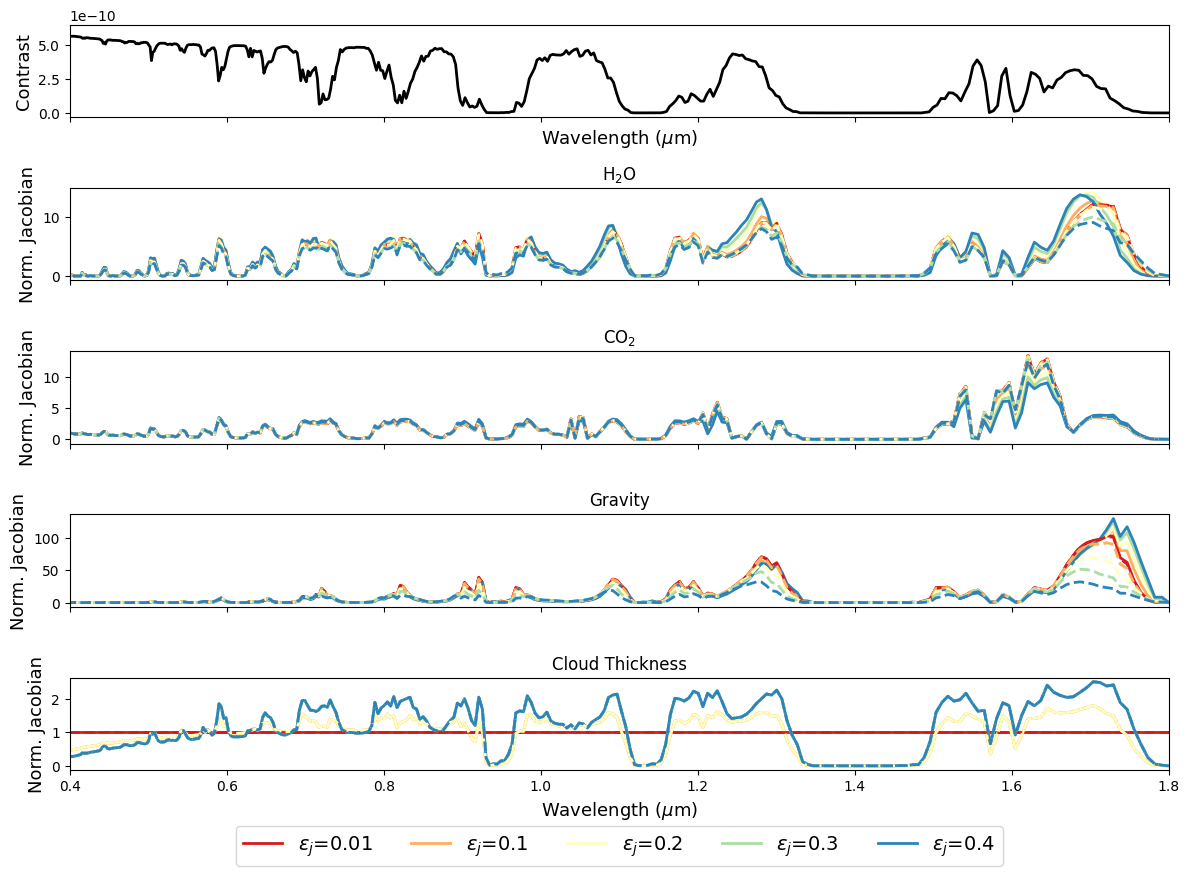

In [10]:
fig,axs = plt.subplots(5,1,figsize=[12,9],sharex=True)

#plot the spectrum for clarity 

axs[0].plot(1e4/xspec,yspec,color='black',linewidth=2)
axs[0].set_ylabel(rf'Contrast',fontsize=13)
axs[0].set_xlabel(rf'Wavelength ($\mu$m)',fontsize=13)
unpacked = [axs[i+1] for i in range(4)]
linestyle='-'

# loop through two different differencing methods
for jm in range(2):
    
    K_rebin = []
    ws = []
    ys = []
    labels = []
    cols =list(jpi.pals.Spectral5)[::-1]
    for ij, d in enumerate(results.keys()):
        for i, ip in enumerate(jac_params):
            # rebin for clarity 
            x,y = jdi.mean_regrid(df['wavenumber'], results[d][jm][:,i],R=200)
            #set zero jacobian to small number since we will normalize and plot in log space
            y[y==0] = 1e-6 
            # normalize jacobian 
            y = jdi.np.abs(y/jdi.np.median(jdi.np.abs(y)))
            ws += [x]
            ys += [y]
            labels += [ip]
            x = np.array(x)

            if jm==1: linestyle='--'
            if jm==0: label=rf'$\epsilon_j$={d}'
            else: label=None
            unpacked[i].plot(1e4/x,y, label=label,color=cols[ij],linestyle=linestyle,linewidth=2)
            unpacked[i].set_title(ip.split('.')[-1].replace('dp','Cloud Thickness').replace('g','G').replace('2',rf'$_2$')
            ,fontsize=12)

            unpacked[i].set_xlim([0.4,1.8])
            unpacked[i].set_ylabel(rf'Norm. Jacobian',fontsize=13)
    unpacked[-1].set_xlabel(rf'Wavelength ($\mu$m)',fontsize=13)

plt.legend(bbox_to_anchor=(0.5, -0.5),#fontsize=10,
                fontsize=14,
                loc = 'upper center', 
            ncol=5)

fig.tight_layout()

## Compute IC statistics using Jacobian 

Above 0.1 looks like it provides a good linear approximation to the Jacobian. Let's proceed and compute IC statistics over an approxite range of resolutions and SNRs. 

PICASO's main package is controled via `ic.Analyze`, which takes in: 

- `jacobian` : number of molecules by number of parameters from function above 

- `error` : absolute error on spectrum. 

For the `error` there are three main options: 

1. could be constant (if any binning is requested it is assumed that the error input is associated  with those new requests. e.g., if R=70 is requested the constant error will be applied to the new R=70 wavenumber grid, not the original.)

2. input array on the same coordinate system as wno_grid. In this case, any binning requests  will also bin the error according to spectres.spectres error binning. 

3. a list [wno_error, error]. in this case wno_error becomes the new wavenumber grid and the jacobian will be binned to this error accordingly.


The other optional arguments set how you want to bin the Jacobian (either with a new wavelength axis or a constant `R`, resolving power)



In [11]:
jac_considered = ic.copy.deepcopy(results[0.1][1])


R = [50,100,150,200,250,300,350,400]
SNR = [5,10,15,20]
SNR_ref = 0.55 #lambda 
min_wave = 0.42 
max_wave = 1.78

#['atmosphere.profile.H2O', 'atmosphere.profile.CO2', 'planet.gravity', 'def.clouds.dp']
prior=[10,10,2,6]

all_results = {}
cases = {}
loss_by_wave = {}
for ir in R: 
    for isnr in SNR: 
        wavegrid = ic.create_grid(min_wave, max_wave, ir)
        xlow,ylow = jdi.mean_regrid(df['wavenumber'],df['albedo'],newx=wavegrid)
        alb_at_ref = np.interp(np.array([1e4/SNR_ref]), xlow,ylow )
        error = alb_at_ref/isnr
        cases[rf'R={ir},SNR={isnr}'] = [wavegrid, wavegrid*0+error]
        IC_analyzer_cl = ic.Analyze(df['wavenumber'], jac_considered, cases[rf'R={ir},SNR={isnr}'] )
        #DOF_SVD = IC_analyzer_cl.degrees_of_freedom_svd()
        SIC = IC_analyzer_cl.shannon_ic(prior) 
        all_results[rf'R={ir},SNR={isnr}'] =SIC

        loss_by_wave[rf'R={ir},SNR={isnr}'] = [ 1e4/IC_analyzer_cl.new_wno , IC_analyzer_cl.loss_by_wave()]



### Infromation Loss using IC Content in bits 

Reproducing Figure 2a, Batalha & Wogan 

/tmp/ipykernel_2018320/1094167858.py:12: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.05)


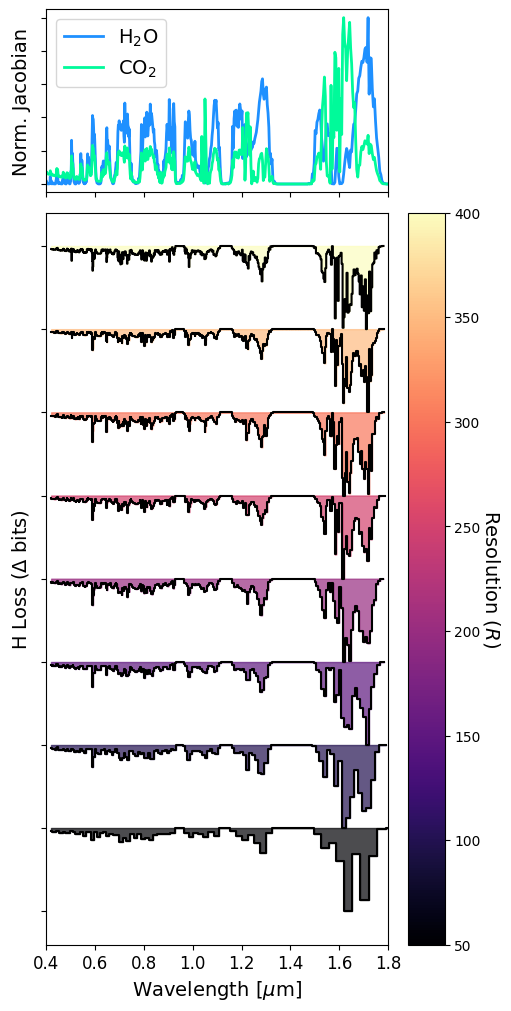

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import copy

fig, (ax_ref, ax) = plt.subplots(2, 1, figsize=(5, 10), sharex=True,
layout="constrained", 
                                 gridspec_kw={'height_ratios': [1, 4]})

# Adjust spacing so the plots are flush (optional)
fig.subplots_adjust(hspace=0.05)

labels = [rf'H$_2$O',rf'CO$_2$']
colors = ['#1E90FF','#00FA9A']
for i in range(2):
    x,y = jdi.mean_regrid(df['wavenumber'], jac_considered[:,i],R=np.max(R))
    ax_ref.plot(1e4/x,np.abs(y/np.max(np.abs(y))), 
    linewidth=2,color=colors[i], label=labels[i])

norm = mcolors.Normalize(vmin=min(R), vmax=max(R))
colormap = cm.magma # Choose your preferred gradient

isnr=10
for ii,ir in enumerate(R): 
    x,y = loss_by_wave[rf'R={ir},SNR={isnr}'][0],copy.deepcopy(np.array(loss_by_wave[rf'R={ir},SNR={isnr}'][1][0]))
    y = y /np.max(np.abs(y))

    color = colormap(norm(ir))

    ax.step(x,np.array(y)+ii,where='mid',color='black')#, zorder=i+2)

    ax.fill_between(x,y+ii, ii+0*x, step='mid', 
                    color=color, alpha=0.7)#, zorder=i+1)

# Add the Colorbar
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm,  ax=ax, pad=0.02)
cbar.set_label('Resolution ($R$)', rotation=270, labelpad=15,fontsize=14)

#ax_ref.set_position(ax.get_position())

ax.set_ylabel(rf'H Loss ($\Delta$ bits)',fontsize=14)
ax.set_xlabel(rf'Wavelength [$\mu$m]',fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax_ref.set_ylabel(rf'Norm. Jacobian',fontsize=14)
ax_ref.legend(fontsize=14)

for i in [ax,ax_ref]:
    i.set_xlim([0.4,1.8])
    i.set_yticklabels([])

### Infromation Loss using 1 $\sigma$ H2O Constraint Interval

Reproducing Figure 2b, Batalha & Wogan 

/tmp/ipykernel_2018320/404046092.py:6: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.05)


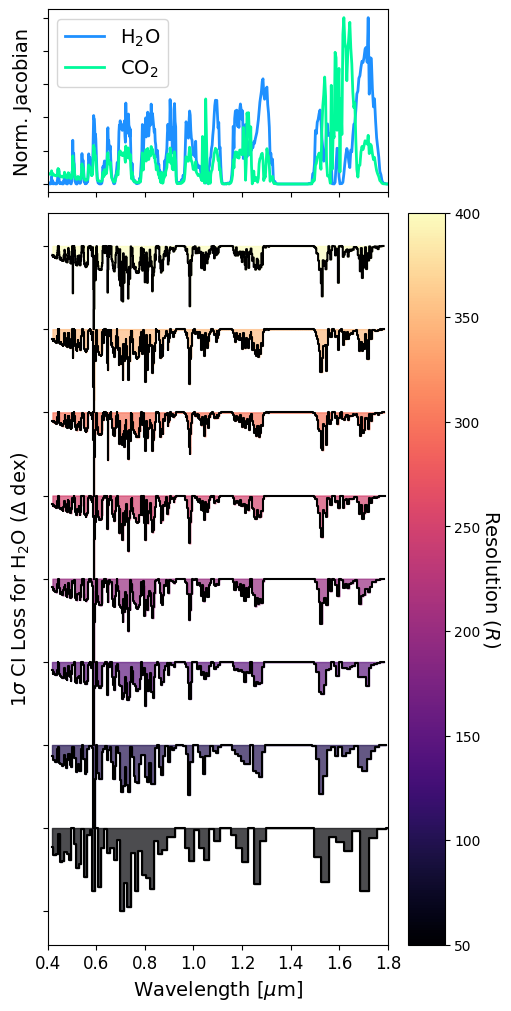

In [13]:
fig, (ax_ref, ax) = plt.subplots(2, 1, figsize=(5, 10), sharex=True,
layout="constrained", 
                                 gridspec_kw={'height_ratios': [1, 4]})

# Adjust spacing so the plots are flush (optional)
fig.subplots_adjust(hspace=0.05)

labels = [rf'H$_2$O',rf'CO$_2$']
colors = ['#1E90FF','#00FA9A']
for i in range(2):
    x,y = jdi.mean_regrid(df['wavenumber'], jac_considered[:,i],R=np.max(R))
    ax_ref.plot(1e4/x,np.abs(y/np.max(np.abs(y))), 
    linewidth=2,color=colors[i], label=labels[i])

norm = mcolors.Normalize(vmin=min(R), vmax=max(R))
colormap = cm.magma # Choose your preferred gradient

isnr=10
for ii,ir in enumerate(R): 
    x = loss_by_wave[rf'R={ir},SNR={isnr}'][0]
    y = copy.deepcopy(np.array([jj[0] for jj in loss_by_wave[rf'R={ir},SNR={isnr}'][1][1]]))
    y = y /np.max(np.abs(y))

    color = colormap(norm(ir))

    ax.step(x,np.array(y)+ii,where='mid',color='black')#, zorder=i+2)

    ax.fill_between(x,y+ii, ii+0*x, step='mid', 
                    color=color, alpha=0.7)#, zorder=i+1)

# Add the Colorbar
sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm,  ax=ax, pad=0.02)
cbar.set_label('Resolution ($R$)', rotation=270, labelpad=15,fontsize=14)

#ax_ref.set_position(ax.get_position())

ax.set_ylabel(rf'1$\sigma$ CI Loss for H$_2$O ($\Delta$ dex)',fontsize=14)
ax.set_xlabel(rf'Wavelength [$\mu$m]',fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax_ref.set_ylabel(rf'Norm. Jacobian',fontsize=14)
ax_ref.legend(fontsize=14)

for i in [ax,ax_ref]:
    i.set_xlim([0.4,1.8])
    i.set_yticklabels([])